# PyTorch CNN-Attention-LSTM on NASA CMAPSS FD001

## Attribution and changes

This notebook adapts the public CMAPSS RUL workflow from Biswajit Sahoo's `rul_codes_open` repository and replaces the TensorFlow/Keras CNN-LSTM with a PyTorch CNN + channel attention + spatial attention + LSTM model.

Main fixes/changes included here:
- consistent CMAPSS column naming
- removal of low-information FD001 columns
- MinMax normalization fitted only on training data
- standard final-window test evaluation, one prediction per test engine
- PyTorch training loop
- RMSE, MAE, R², and NASA S-score
- error analysis plots


In [18]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import random
import tensorflow as tf
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 313
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [19]:
index_names = ['unit_number', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = ['s_{}'.format(i+1) for i in range(0, 21)]
col_names = index_names + setting_names + sensor_names


train_df = pd.read_csv("CMAPSSData/train_FD001.txt", sep='\s+', header=None, names=col_names)
test_df = pd.read_csv("CMAPSSData/test_FD001.txt", sep='\s+', header=None, names=col_names)


RUL = pd.read_csv("CMAPSSData/RUL_FD001.txt", sep='\s+', header=None, names=['RUL'])

print(f"Length of RUL: {len(RUL)}")
print(f"Length of train_df: {len(train_df)}")
print(f"Length of test_df: {len(test_df)}")



Length of RUL: 100
Length of train_df: 20631
Length of test_df: 13096


In [20]:
RUL.head()

,RUL
0,112
1,98
2,69
3,82
4,91


In [21]:
train_df.head()

,unit_number,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [22]:
test_df.head()

,unit_number,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


### Change column names for simplicity

In [23]:
column_names = []
for i in range(25):
    if i == 0: column_names.append("unit")
    if i == 1: column_names.append("time")
    if i > 1 and i < 5: column_names.append("c" + str(i-1))
    if i >= 4: column_names.append("s" + str(i-3))
print(column_names)
len(column_names)

['unit', 'time', 'c1', 'c2', 'c3', 's1', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 's9', 's10', 's11', 's12', 's13', 's14', 's15', 's16', 's17', 's18', 's19', 's20', 's21']


26

In [24]:
# Apply simplified column names consistently.
train_df.columns = column_names
test_df.columns = column_names

# RUL file contains final true RUL for each test engine.
RUL.columns = ['rul']
RUL['unit'] = range(1, len(RUL) + 1)


In [25]:
train_df.head()

,unit,time,c1,c2,c3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [26]:
test_df.head()

,unit,time,c1,c2,c3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


In [27]:
RUL.head()

,rul,unit
0,112,1
1,98,2
2,69,3
3,82,4
4,91,5


## Preprocessing

### Data normalization

In [28]:
# Cast operating-condition and sensor columns to float.
# Scaling is performed after non-informative columns are dropped.
cols = train_df.columns[2:]
train_df[cols] = train_df[cols].astype(float)

test_df[cols] = test_df[cols].astype(float)


In [29]:
train_df.head()

,unit,time,c1,c2,c3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392.0,2388.0,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392.0,2388.0,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390.0,2388.0,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392.0,2388.0,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393.0,2388.0,100.0,38.90,23.4044


In [30]:
test_df.head()

,unit,time,c1,c2,c3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392.0,2388.0,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393.0,2388.0,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393.0,2388.0,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391.0,2388.0,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390.0,2388.0,100.0,38.99,23.4130


In [31]:
# Seed already set in the import cell. This cell is kept for readability.
SEED = 313
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)


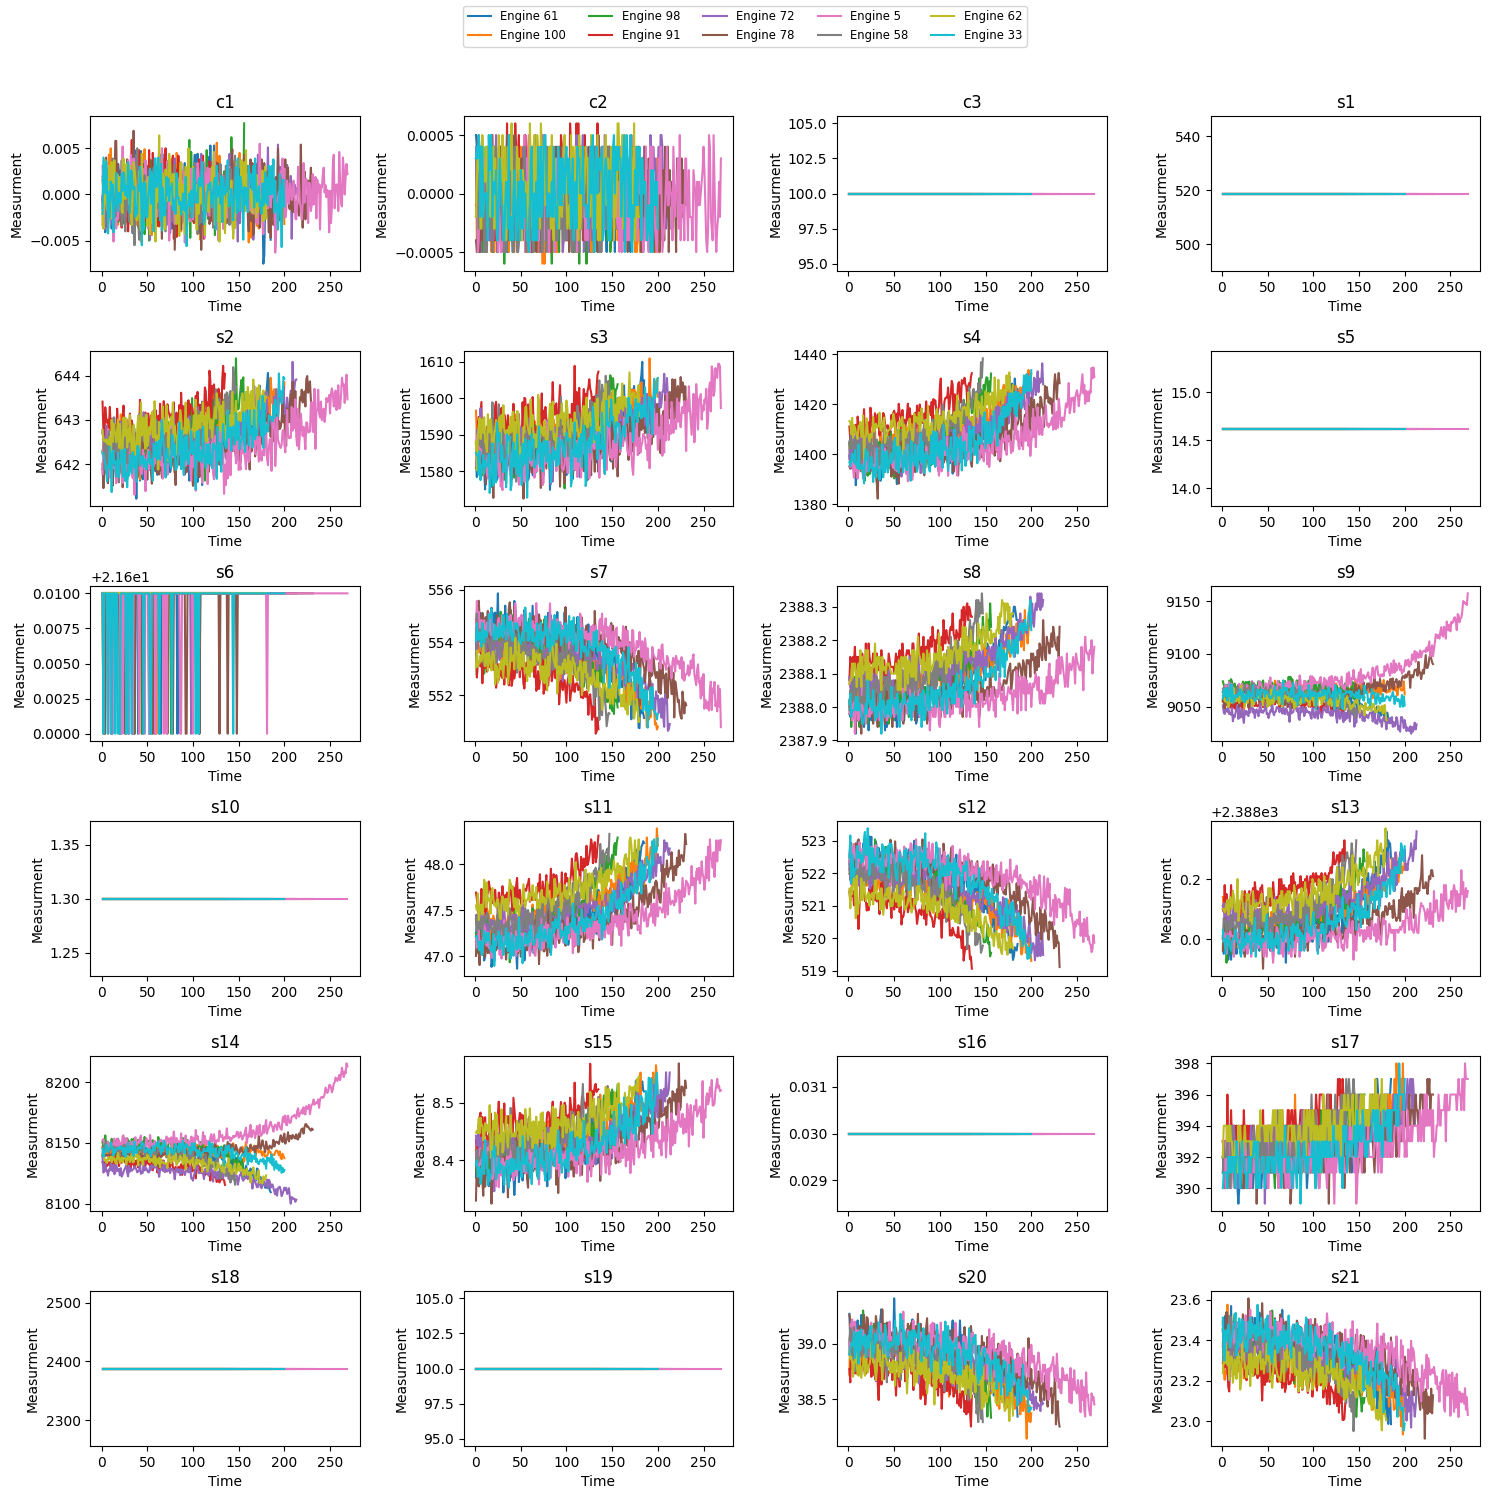

In [32]:
engines = train_df['unit'].unique()
selected_engines = np.random.choice(engines, 10, replace=False)

fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(15, 15))
axes = axes.flatten()
sensor_cols = [col for col in train_df.columns if col.startswith('s') or col.startswith('c')]

lines = []
labels = []

for engine in selected_engines:
    line, = plt.plot([], [], label=f'Engine {engine}')
    lines.append(line)
    labels.append(f'Engine {engine}')

for i, sensor in enumerate(sensor_cols):
    ax = axes[i]
    for engine in selected_engines:
        engine_data = train_df[train_df['unit'] == engine]
        ax.plot(engine_data['time'], engine_data[sensor])
    ax.set_title(sensor)
    ax.set_xlabel('Time')
    ax.set_ylabel('Measurment')

fig.legend(lines, labels, loc='upper center', ncol=5, fontsize='small')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


### Data selection

In [33]:
# Drop nearly constant / low-information columns commonly removed for FD001.
non_informative_cols = ['c3', 's1', 's5', 's6', 's10', 's16', 's18', 's19']
train_df = train_df.drop(non_informative_cols, axis=1)
test_df  = test_df.drop(non_informative_cols, axis=1)

# Normalize inputs using train-only fit to avoid data leakage.
# Include remaining operating-condition columns and sensors as model features.
feature_columns = [col for col in train_df.columns if col.startswith('c') or col.startswith('s')]

scaler = MinMaxScaler()
train_df[feature_columns] = scaler.fit_transform(train_df[feature_columns])
test_df[feature_columns] = scaler.transform(test_df[feature_columns])

print(f"Number of model features after dropping columns: {len(feature_columns)}")
print(feature_columns)


Number of model features after dropping columns: 16
['c1', 'c2', 's2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']


In the following section we are computing RUL for test set and add it as a column to its corresponding df.

In [34]:
max_values_df1 = test_df.groupby('unit')['time'].transform("max")
new_df = pd.DataFrame({'max_value': max_values_df1, 'unit': test_df['unit']})
new_df.drop_duplicates(inplace=True)
new_df.reset_index(drop=True, inplace=True)

In [35]:
new_df

,max_value,unit
0,31,1
1,49,2
2,126,3
3,106,4
4,98,5
...,...,...
95,97,96
96,134,97
97,121,98
98,97,99


In [36]:
new_df['sum'] = new_df['max_value'] + RUL['rul']

In [37]:
new_df

,max_value,unit,sum
0,31,1,143
1,49,2,147
2,126,3,195
3,106,4,188
4,98,5,189
...,...,...,...
95,97,96,234
96,134,97,216
97,121,98,180
98,97,99,214


In [38]:
test_df = pd.merge(new_df, test_df, on='unit')
test_df['rul'] = test_df['sum'] - test_df['time']

In [39]:
test_df

,max_value,unit,sum,time,c1,c2,s2,s3,s4,s7,...,s9,s11,s12,s13,s14,s15,s17,s20,s21,rul
0,31,1,143,1,0.632184,0.750000,0.545181,0.310661,0.269413,0.652174,...,0.127614,0.208333,0.646055,0.220588,0.132160,0.308965,0.333333,0.558140,0.661834,142
1,31,1,143,2,0.344828,0.250000,0.150602,0.379551,0.222316,0.805153,...,0.146684,0.386905,0.739872,0.264706,0.204768,0.213159,0.416667,0.682171,0.686827,141
2,31,1,143,3,0.517241,0.583333,0.376506,0.346632,0.322248,0.685990,...,0.158081,0.386905,0.699360,0.220588,0.155640,0.458638,0.416667,0.728682,0.721348,140
3,31,1,143,4,0.741379,0.500000,0.370482,0.285154,0.408001,0.679549,...,0.105717,0.255952,0.573561,0.250000,0.170090,0.257022,0.250000,0.666667,0.662110,139
4,31,1,143,5,0.580460,0.500000,0.391566,0.352082,0.332039,0.694042,...,0.102396,0.273810,0.737740,0.220588,0.152751,0.300885,0.166667,0.658915,0.716377,138
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13091,198,100,218,194,0.781609,0.500000,0.611446,0.619359,0.566172,0.573269,...,0.541326,0.500000,0.426439,0.176471,0.584890,0.564063,0.500000,0.395349,0.418669,24
13092,198,100,218,195,0.436782,0.416667,0.605422,0.537388,0.671843,0.542673,...,0.533743,0.446429,0.503198,0.308824,0.572350,0.485956,0.583333,0.333333,0.528721,23
13093,198,100,218,196,0.465517,0.250000,0.671687,0.482014,0.414754,0.513688,...,0.561249,0.428571,0.530917,0.235294,0.605326,0.507888,0.583333,0.372093,0.429301,22
13094,198,100,218,197,0.281609,0.583333,0.617470,0.522128,0.626435,0.566828,...,0.570403,0.452381,0.562900,0.294118,0.622046,0.562524,0.583333,0.403101,0.518779,21


Calculate RUL for train set

In [40]:
def calculate_rul(df):
    max_cycles = df.groupby('unit')['time'].max().reset_index()
    max_cycles.columns = ['unit', 'max_time']
    df = df.merge(max_cycles, on='unit')
    df['rul'] = df['max_time'] - df['time']
    df = df.drop(columns=['max_time'])
    return df

train_df = calculate_rul(train_df)

In [41]:
train_df.head()

,unit,time,c1,c2,s2,s3,s4,s7,s8,s9,s11,s12,s13,s14,s15,s17,s20,s21,rul
0,1,1,0.459770,0.166667,0.183735,0.406802,0.309757,0.726248,0.242424,0.109755,0.369048,0.633262,0.205882,0.199608,0.363986,0.333333,0.713178,0.724662,191
1,1,2,0.609195,0.250000,0.283133,0.453019,0.352633,0.628019,0.212121,0.100242,0.380952,0.765458,0.279412,0.162813,0.411312,0.333333,0.666667,0.731014,190
2,1,3,0.252874,0.750000,0.343373,0.369523,0.370527,0.710145,0.272727,0.140043,0.250000,0.795309,0.220588,0.171793,0.357445,0.166667,0.627907,0.621375,189
3,1,4,0.540230,0.500000,0.343373,0.256159,0.331195,0.740741,0.318182,0.124518,0.166667,0.889126,0.294118,0.174889,0.166603,0.333333,0.573643,0.662386,188
4,1,5,0.390805,0.333333,0.349398,0.257467,0.404625,0.668277,0.242424,0.149960,0.255952,0.746269,0.235294,0.174734,0.402078,0.416667,0.589147,0.704502,187


Label data using the threshold 

In [42]:
# Classification label threshold and optional capped RUL for regression.
time_window = 50
RUL_CAP = 125

train_df['rul'] = train_df['rul'].clip(upper=RUL_CAP)
test_df['rul'] = test_df['rul'].clip(upper=RUL_CAP)

train_df['label'] = train_df['rul'].apply(lambda x: 0 if x <= time_window else 1)
test_df['label']  = test_df['rul'].apply(lambda x: 0 if x <= time_window else 1)


In [43]:
train_df.head()

,unit,time,c1,c2,s2,s3,s4,s7,s8,s9,s11,s12,s13,s14,s15,s17,s20,s21,rul,label
0,1,1,0.459770,0.166667,0.183735,0.406802,0.309757,0.726248,0.242424,0.109755,0.369048,0.633262,0.205882,0.199608,0.363986,0.333333,0.713178,0.724662,125,1
1,1,2,0.609195,0.250000,0.283133,0.453019,0.352633,0.628019,0.212121,0.100242,0.380952,0.765458,0.279412,0.162813,0.411312,0.333333,0.666667,0.731014,125,1
2,1,3,0.252874,0.750000,0.343373,0.369523,0.370527,0.710145,0.272727,0.140043,0.250000,0.795309,0.220588,0.171793,0.357445,0.166667,0.627907,0.621375,125,1
3,1,4,0.540230,0.500000,0.343373,0.256159,0.331195,0.740741,0.318182,0.124518,0.166667,0.889126,0.294118,0.174889,0.166603,0.333333,0.573643,0.662386,125,1
4,1,5,0.390805,0.333333,0.349398,0.257467,0.404625,0.668277,0.242424,0.149960,0.255952,0.746269,0.235294,0.174734,0.402078,0.416667,0.589147,0.704502,125,1


In [44]:
test_df.head()

,max_value,unit,sum,time,c1,c2,s2,s3,s4,s7,...,s11,s12,s13,s14,s15,s17,s20,s21,rul,label
0,31,1,143,1,0.632184,0.750000,0.545181,0.310661,0.269413,0.652174,...,0.208333,0.646055,0.220588,0.132160,0.308965,0.333333,0.558140,0.661834,125,1
1,31,1,143,2,0.344828,0.250000,0.150602,0.379551,0.222316,0.805153,...,0.386905,0.739872,0.264706,0.204768,0.213159,0.416667,0.682171,0.686827,125,1
2,31,1,143,3,0.517241,0.583333,0.376506,0.346632,0.322248,0.685990,...,0.386905,0.699360,0.220588,0.155640,0.458638,0.416667,0.728682,0.721348,125,1
3,31,1,143,4,0.741379,0.500000,0.370482,0.285154,0.408001,0.679549,...,0.255952,0.573561,0.250000,0.170090,0.257022,0.250000,0.666667,0.662110,125,1
4,31,1,143,5,0.580460,0.500000,0.391566,0.352082,0.332039,0.694042,...,0.273810,0.737740,0.220588,0.152751,0.300885,0.166667,0.658915,0.716377,125,1


In [45]:
# Use the normalized feature columns, including operating conditions and sensors.
# For standard CMAPSS test evaluation, use only the final available window for each test engine.

if 'feature_columns' not in globals():
    feature_columns = [col for col in train_df.columns if col.startswith('c') or col.startswith('s')]

def create_time_windows_train(df, window_size, stride=1):
    engine_ids = df['unit'].unique()
    X, y_reg, y_clf = [], [], []
    for engine_id in engine_ids:
        engine_df = df[df['unit'] == engine_id].sort_values('time')
        for start in range(0, len(engine_df) - window_size + 1, stride):
            end = start + window_size
            window = engine_df.iloc[start:end]
            X.append(window[feature_columns].values)
            y_reg.append(window['rul'].values[-1])
            y_clf.append(window['label'].values[-1])
    return np.array(X), np.array(y_reg), np.array(y_clf)

def create_time_windows_test(df, window_size, stride=1):
    engine_ids = df['unit'].unique()
    X_reg, X_clf, y_reg, y_clf = [], [], [], []

    for engine_id in engine_ids:
        engine_df = df[df['unit'] == engine_id].sort_values('time')
        n = len(engine_df)

        # Classification/all-window samples.
        for start in range(0, n - window_size + 1, stride):
            end = start + window_size
            window = engine_df.iloc[start:end]
            X_clf.append(window[feature_columns].values)
            y_clf.append(window['label'].values[-1])

        # Regression benchmark: one final window per engine.
        if n >= window_size:
            final_window = engine_df.iloc[-window_size:]
        else:
            # Left-pad very short engines by repeating the first row.
            pad_len = window_size - n
            pad = pd.concat([engine_df.iloc[[0]]] * pad_len, ignore_index=True)
            final_window = pd.concat([pad, engine_df], ignore_index=True)

        X_reg.append(final_window[feature_columns].values)
        y_reg.append(engine_df['rul'].values[-1])

    return np.array(X_reg), np.array(X_clf), np.array(y_reg), np.array(y_clf)

def create_time_windows_all(df, window_size, stride=1):
    # Extra diagnostic only; not the standard CMAPSS benchmark metric.
    return create_time_windows_train(df, window_size, stride)

window_size = 30
X_train, y_reg_train, y_clf_train = create_time_windows_train(train_df, window_size)
X_reg_test, X_clf_test, y_reg_test, y_clf_test = create_time_windows_test(test_df, window_size)

input_shape = (X_train.shape[1], X_train.shape[2])
print("input_shape:", input_shape)


input_shape: (30, 16)


In [46]:
# Extra diagnostic set: all test windows. Do not use this as the main CMAPSS benchmark.
X_reg_test_all, y_reg_test_all, y_clf_test_all = create_time_windows_all(test_df, window_size)


In [47]:
print(f"Number of samples for training in classification/regression task: {len(X_train)}")
print(f"Number of samples for testing in classification task:             {len(X_clf_test)}")
print(f"Number of samples for testing in regression task:                 {len(X_reg_test)}")

Number of samples for training in classification/regression task: 17731
Number of samples for testing in classification task:             10196
Number of samples for testing in regression task:                 100


In [48]:
print(f"X_train shape:     {X_train.shape} \
      \ny_reg_train shape: {y_reg_train.shape} \
      \ny_clf_train shape: {y_clf_train.shape} \
      \nX_reg_test shape:  {X_reg_test.shape}  \
      \ny_reg_test shape:  {y_reg_test.shape} \
      \nX_clf_test shape:  {X_clf_test.shape} \
      \ny_clf_test shape:  {y_clf_test.shape}")

X_train shape:     (17731, 30, 16)       
y_reg_train shape: (17731,)       
y_clf_train shape: (17731,)       
X_reg_test shape:  (100, 30, 16)        
y_reg_test shape:  (100,)       
X_clf_test shape:  (10196, 30, 16)       
y_clf_test shape:  (10196,)


In [49]:
print(f"Number of healthy condition samples: {np.sum(y_clf_train == 1)}")
print(f"Number of faulty condition samples:  {np.sum(y_clf_train == 0)}")

Number of healthy condition samples: 12631
Number of faulty condition samples:  5100


# PyTorch CNN + Attention + LSTM Regression

This model is the variant architecture. It uses 2D convolutions over the time-by-feature input matrix, then channel attention and spatial attention, followed by an LSTM regression head.

Input to the PyTorch model has shape `(batch, 1, window_size, num_features)`.

In [50]:
# ------------------------------------------------------------
# PyTorch datasets and dataloaders
# ------------------------------------------------------------

def to_torch_4d(X):
    """Convert numpy array from (N, T, F) to torch tensor (N, 1, T, F)."""
    X = np.asarray(X, dtype=np.float32)
    return torch.tensor(X).unsqueeze(1)

X_train_t = to_torch_4d(X_train)
y_train_t = torch.tensor(np.asarray(y_reg_train, dtype=np.float32)).view(-1, 1)

X_test_t = to_torch_4d(X_reg_test)
y_test_t = torch.tensor(np.asarray(y_reg_test, dtype=np.float32)).view(-1, 1)

full_dataset = TensorDataset(X_train_t, y_train_t)
val_size = int(0.2 * len(full_dataset))
train_size = len(full_dataset) - val_size

generator = torch.Generator().manual_seed(SEED)
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size], generator=generator)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=BATCH_SIZE, shuffle=False)

print("X_train_t:", X_train_t.shape)
print("y_train_t:", y_train_t.shape)
print("X_test_t: ", X_test_t.shape)
print("y_test_t: ", y_test_t.shape)


X_train_t: torch.Size([17731, 1, 30, 16])
y_train_t: torch.Size([17731, 1])
X_test_t:  torch.Size([100, 1, 30, 16])
y_test_t:  torch.Size([100, 1])


In [51]:
# ------------------------------------------------------------
# Channel attention and spatial attention blocks
# Similar in spirit to CBAM-style attention.
# ------------------------------------------------------------

class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction_rate=2):
        super().__init__()
        hidden = max(1, channels // reduction_rate)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.shared_mlp = nn.Sequential(
            nn.Conv2d(channels, hidden, kernel_size=1, bias=False),
            nn.ReLU(),
            nn.Conv2d(hidden, channels, kernel_size=1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.shared_mlp(self.avg_pool(x))
        max_out = self.shared_mlp(self.max_pool(x))
        attention = self.sigmoid(avg_out + max_out)
        return x * attention


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=3):
        super().__init__()
        padding = kernel_size // 2
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        attention_input = torch.cat([avg_out, max_out], dim=1)
        attention = self.sigmoid(self.conv(attention_input))
        return x * attention


In [52]:
# ------------------------------------------------------------
# CNN + Channel Attention + Spatial Attention + LSTM model
# ------------------------------------------------------------

class CNNAttentionLSTM(nn.Module):
    def __init__(self, window_size, num_features, lstm_hidden=128):
        super().__init__()

        self.cnn = nn.Sequential(
            # Input: (B, 1, T, F)
            nn.Conv2d(1, 10, kernel_size=(10, 3), padding="same"),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 2), padding=0, ceil_mode=True),

            nn.Conv2d(10, 10, kernel_size=(3, 3), padding="same"),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 2), padding=0, ceil_mode=True),

            nn.Conv2d(10, 10, kernel_size=(5, 5), padding="same"),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 2), padding=0, ceil_mode=True),
        )

        self.channel_attention = ChannelAttention(channels=10, reduction_rate=2)
        self.spatial_attention = SpatialAttention(kernel_size=3)

        # Infer LSTM input size after CNN using a dummy tensor.
        with torch.no_grad():
            dummy = torch.zeros(1, 1, window_size, num_features)
            out = self.cnn(dummy)
            out = self.channel_attention(out)
            out = self.spatial_attention(out)
            _, c, t_reduced, f_reduced = out.shape
            self.lstm_input_size = c * f_reduced
            self.lstm_time_steps = t_reduced

        self.lstm = nn.LSTM(
            input_size=self.lstm_input_size,
            hidden_size=lstm_hidden,
            batch_first=True
        )
        self.fc = nn.Linear(lstm_hidden, 1)

    def forward(self, x):
        # x: (B, 1, T, F)
        x = self.cnn(x)
        x = self.channel_attention(x)
        x = self.spatial_attention(x)

        # Convert CNN feature map to sequence for LSTM.
        # (B, C, T', F') -> (B, T', C*F')
        x = x.permute(0, 2, 1, 3).contiguous()
        x = x.view(x.size(0), x.size(1), -1)

        lstm_out, _ = self.lstm(x)
        last_hidden = lstm_out[:, -1, :]
        return self.fc(last_hidden)


window_size = X_train.shape[1]
num_features = X_train.shape[2]

model = CNNAttentionLSTM(window_size=window_size, num_features=num_features, lstm_hidden=128).to(device)
print(model)
print("LSTM input size:", model.lstm_input_size)
print("LSTM time steps:", model.lstm_time_steps)


CNNAttentionLSTM(
  (cnn): Sequential(
    (0): Conv2d(1, 10, kernel_size=(10, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=True)
    (3): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (4): ReLU()
    (5): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=True)
    (6): Conv2d(10, 10, kernel_size=(5, 5), stride=(1, 1), padding=same)
    (7): ReLU()
    (8): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=True)
  )
  (channel_attention): ChannelAttention(
    (avg_pool): AdaptiveAvgPool2d(output_size=1)
    (max_pool): AdaptiveMaxPool2d(output_size=1)
    (shared_mlp): Sequential(
      (0): Conv2d(10, 5, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): ReLU()
      (2): Conv2d(5, 10, kernel_size=(1, 1), stride=(1, 1), bias=False)
    )
    (sigmoid): Sigmoid()
  )
  (spatial_attention): SpatialAttention(
    

/Users/vinithapalani/miniconda3/envs/rul_env/lib/python3.11/site-packages/torch/nn/modules/conv.py:548: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Convolution.cpp:1025.)
  return F.conv2d(


In [53]:
# ------------------------------------------------------------
# Training utilities
# ------------------------------------------------------------

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)

    return total_loss / len(loader.dataset)


def evaluate_loss(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            total_loss += loss.item() * X_batch.size(0)

    return total_loss / len(loader.dataset)


def predict(model, loader, device):
    model.eval()
    preds_list, y_list = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            preds = model(X_batch).cpu().numpy().reshape(-1)
            preds_list.append(preds)
            y_list.append(y_batch.numpy().reshape(-1))

    return np.concatenate(y_list), np.concatenate(preds_list)


In [54]:
# ------------------------------------------------------------
# Train PyTorch model with early stopping
# ------------------------------------------------------------

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5
)

EPOCHS = 100
PATIENCE = 10
best_val_loss = float("inf")
best_state = None
patience_counter = 0

train_losses = []
val_losses = []

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss = evaluate_loss(model, val_loader, criterion, device)
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch == 1 or epoch % 5 == 0:
        print(f"Epoch {epoch:03d} | train MSE: {train_loss:.4f} | val MSE: {val_loss:.4f}")

    if patience_counter >= PATIENCE:
        print(f"Early stopping at epoch {epoch}.")
        break

if best_state is not None:
    model.load_state_dict(best_state)


Epoch 001 | train MSE: 5630.6415 | val MSE: 3831.6314
Epoch 005 | train MSE: 1597.6712 | val MSE: 1226.4440
Epoch 010 | train MSE: 358.8713 | val MSE: 358.7343
Epoch 015 | train MSE: 290.8646 | val MSE: 282.1509
Epoch 020 | train MSE: 252.5802 | val MSE: 265.2444
Epoch 025 | train MSE: 216.9901 | val MSE: 216.2731
Epoch 030 | train MSE: 195.1318 | val MSE: 191.0141
Epoch 035 | train MSE: 179.7317 | val MSE: 185.8777
Epoch 040 | train MSE: 168.1519 | val MSE: 175.4487
Epoch 045 | train MSE: 162.1444 | val MSE: 200.3429
Epoch 050 | train MSE: 157.9690 | val MSE: 174.6112
Epoch 055 | train MSE: 144.3874 | val MSE: 164.9969
Epoch 060 | train MSE: 135.9850 | val MSE: 138.2356
Epoch 065 | train MSE: 128.2868 | val MSE: 137.7592
Epoch 070 | train MSE: 123.5079 | val MSE: 135.9043
Epoch 075 | train MSE: 119.9336 | val MSE: 134.0097
Epoch 080 | train MSE: 114.2781 | val MSE: 123.3628
Epoch 085 | train MSE: 111.4694 | val MSE: 131.9654
Epoch 090 | train MSE: 107.0008 | val MSE: 126.1950
Epoch 09

In [55]:
# ------------------------------------------------------------
# Evaluation metrics: RMSE, MAE, R2, NASA S-score
# ------------------------------------------------------------

def compute_s_score(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    d = y_pred - y_true

    score = np.where(
        d < 0,
        np.exp(-d / 13.0) - 1.0,
        np.exp(d / 10.0) - 1.0
    )
    return float(np.sum(score))


def print_regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    s_score = compute_s_score(y_true, y_pred)

    print(f"Mean Absolute Error (MAE):       {mae:.3f}")
    print(f"Mean Squared Error (MSE):        {mse:.3f}")
    print(f"Root Mean Squared Error (RMSE):  {rmse:.3f}")
    print(f"R-squared (R2):                  {r2:.3f}")
    print(f"NASA S-score:                    {s_score:.3f}")

    return {
        "mae": mae,
        "mse": mse,
        "rmse": rmse,
        "r2": r2,
        "s_score": s_score,
    }

# Standard CMAPSS benchmark: one final-window prediction per test engine.
y_reg_test_final, y_reg_pred_final = predict(model, test_loader, device)
metrics = print_regression_metrics(y_reg_test_final, y_reg_pred_final)


Mean Absolute Error (MAE):       11.184
Mean Squared Error (MSE):        223.597
Root Mean Squared Error (RMSE):  14.953
R-squared (R2):                  0.861
NASA S-score:                    392.561


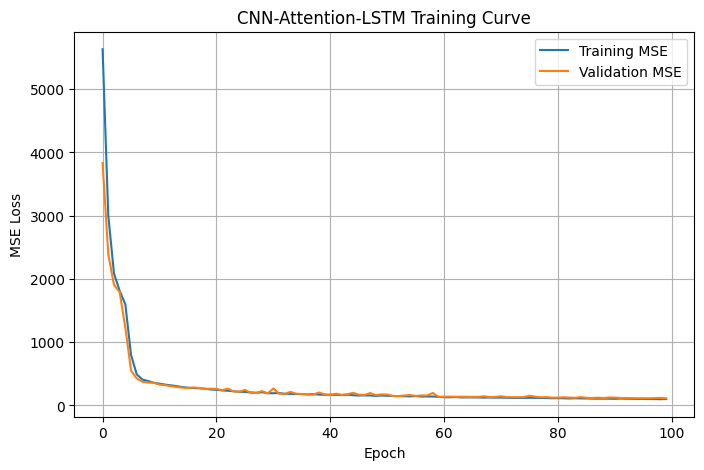

In [56]:
# ------------------------------------------------------------
# Training curve
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Training MSE")
plt.plot(val_losses, label="Validation MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("CNN-Attention-LSTM Training Curve")
plt.legend()
plt.grid(True)
plt.show()


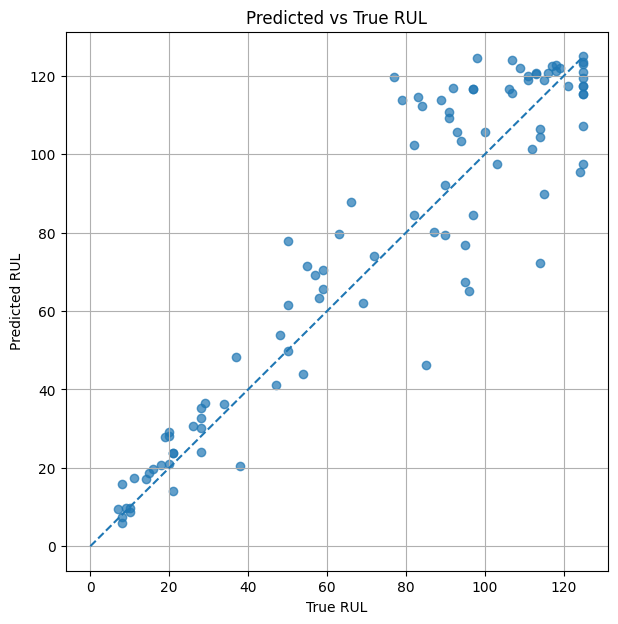

In [57]:
# ------------------------------------------------------------
# Predicted vs true RUL
# ------------------------------------------------------------

plt.figure(figsize=(7, 7))
plt.scatter(y_reg_test_final, y_reg_pred_final, alpha=0.7)
plt.plot([0, max(y_reg_test_final)], [0, max(y_reg_test_final)], linestyle="--")
plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title("Predicted vs True RUL")
plt.grid(True)
plt.show()


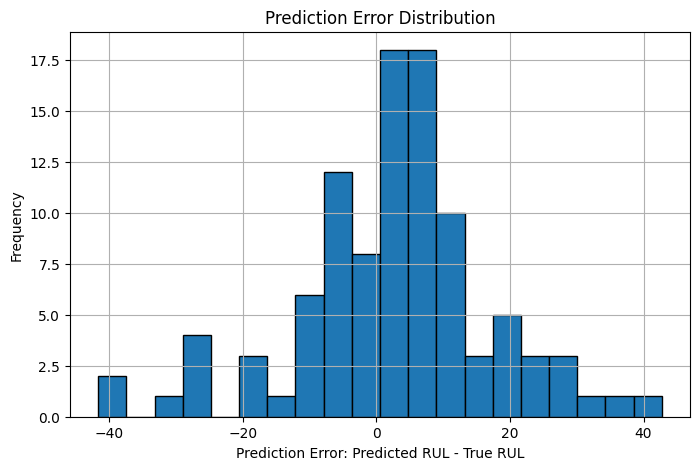

,unit,true_rul,predicted_rul,error
0,1,112.0,101.228149,-10.771851
1,2,98.0,124.446091,26.446091
2,3,69.0,62.082603,-6.917397
3,4,82.0,102.327438,20.327438
4,5,91.0,110.745262,19.745262


In [58]:
# ------------------------------------------------------------
# Error distribution and results table
# ------------------------------------------------------------

errors = y_reg_pred_final - y_reg_test_final

plt.figure(figsize=(8, 5))
plt.hist(errors, bins=20, edgecolor="black")
plt.xlabel("Prediction Error: Predicted RUL - True RUL")
plt.ylabel("Frequency")
plt.title("Prediction Error Distribution")
plt.grid(True)
plt.show()

results_df = pd.DataFrame({
    "unit": np.arange(1, len(y_reg_test_final) + 1),
    "true_rul": y_reg_test_final,
    "predicted_rul": y_reg_pred_final,
    "error": errors
})

results_df.head()


In [59]:
# ------------------------------------------------------------
# Optional: save checkpoint for reproducibility
# ------------------------------------------------------------

checkpoint_path = "cnn_attention_lstm_fd001.pt"
torch.save({
    "model_state_dict": model.state_dict(),
    "window_size": window_size,
    "num_features": num_features,
    "feature_columns": feature_columns,
    "metrics": metrics,
}, checkpoint_path)

print(f"Saved checkpoint to {checkpoint_path}")


Saved checkpoint to cnn_attention_lstm_fd001.pt
